# Stratification
Previously, we defaulted to `KFold` or `ShuffleSplit` cross-validation strategies. There are several other strategies, such as stratification.

In [1]:
from sklearn.datasets import load_iris

data, target = load_iris(as_frame=True, return_X_y=True)

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

model = make_pipeline(
    StandardScaler(),
    LogisticRegression()
)

In [3]:
import numpy as np
from sklearn.model_selection import KFold

data_random = np.random.randn(9, 1)
cv = KFold(n_splits=3)

for train_index, test_index in cv.split(data_random):
    print("TRAIN: ", train_index, "TEST: ", test_index)

TRAIN:  [3 4 5 6 7 8] TEST:  [0 1 2]
TRAIN:  [0 1 2 6 7 8] TEST:  [3 4 5]
TRAIN:  [0 1 2 3 4 5] TEST:  [6 7 8]


In this `KFold`, we use 3 splits; where there are 3 samples (1 fold) for testing and 6 samples (2 folds) for training every split. `KFold` does not shuffle by default.

In [4]:
from sklearn.model_selection import cross_validate

results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.000 ± 0.000


This model cannot correctly classify any sample in any cross-validation split. Shown below, this is because the target vector `target` is ordered. When using `KFold`, this has some consequences.

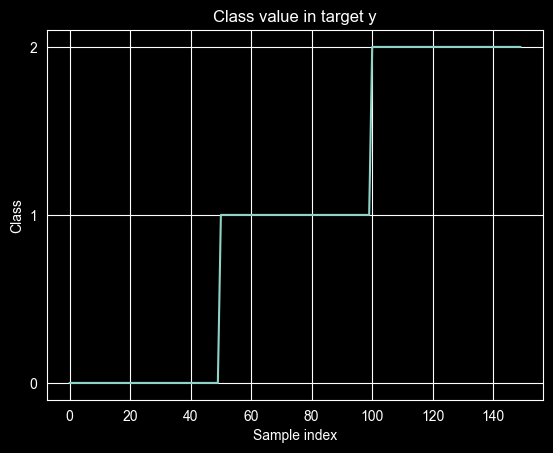

In [5]:
import matplotlib.pyplot as plt

target.plot()
plt.xlabel("Sample index")
plt.ylabel("Class")
plt.yticks(target.unique())
_ = plt.title("Class value in target y")

In [8]:
import pandas as pd

n_splits = 3
cv = KFold(n_splits=n_splits)

train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())

In [9]:
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
train_cv_counts

,Fold #0,Fold #1,Fold #2
Class label,,,
1,50.0,NaN,50.0
2,50.0,50.0,NaN
0,NaN,50.0,50.0


In [10]:
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts.index.name = "Class label"
test_cv_counts

,Fold #0,Fold #1,Fold #2
Class label,,,
0,50.0,NaN,NaN
1,NaN,50.0,NaN
2,NaN,NaN,50.0


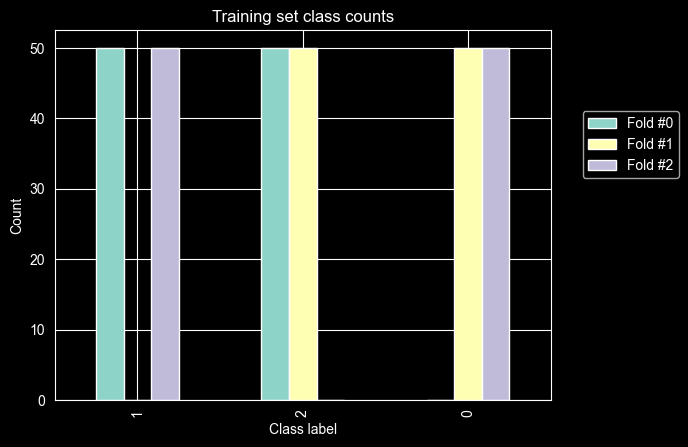

In [11]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set class counts")

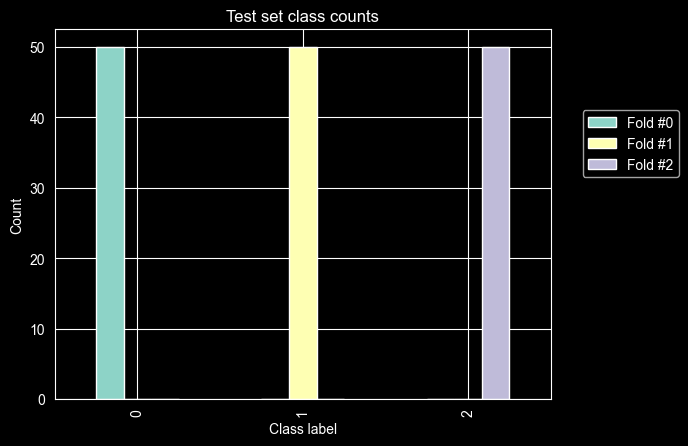

In [12]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set class counts")

As can be seen, due to the ordering, only two of the three classes are present in the training set on each split, and all the samples of the remaining class is used as a test set. Thus, we need to shuffle the data before splitting.

In [13]:
cv = KFold(n_splits=3, shuffle=True, random_state=0)
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.953 ± 0.009


In [14]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

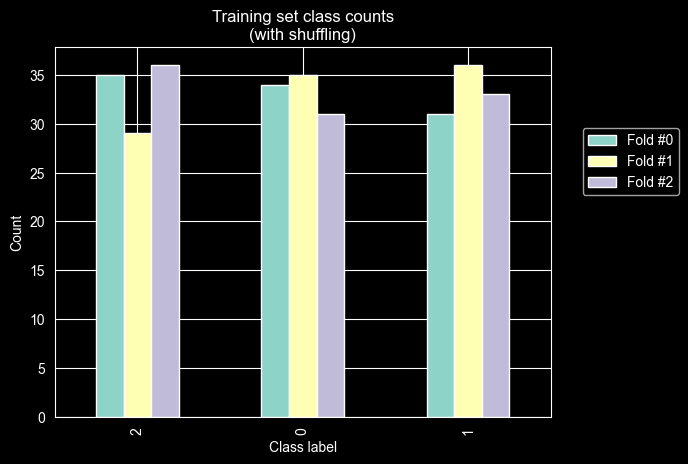

In [17]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set class counts\n(with shuffling)")

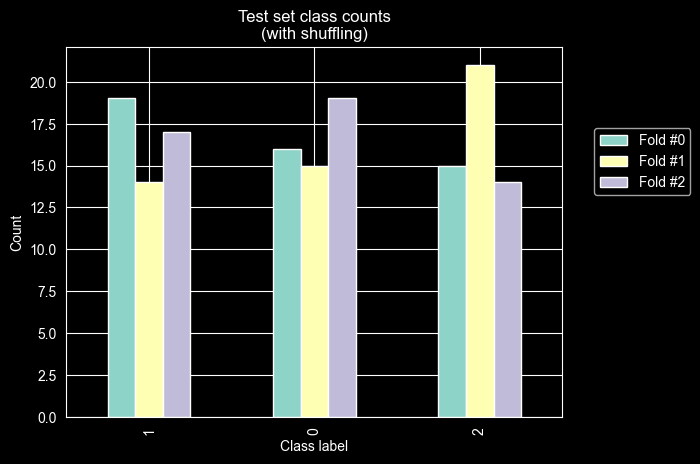

In [18]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set class counts\n(with shuffling)")

Neither the training and testing sets have the same class frequencies as the original dataset. However, one may want to split the data and preserve the original class frequencies. This is called **stratification**. Some strategies implement stratification, like `KFold`:

In [19]:
from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(n_splits=3)

In [20]:
results = cross_validate(model, data, target, cv=cv)
test_score = results["test_score"]
print(
    f"The average accuracy is {test_score.mean():.3f} ± {test_score.std():.3f}"
)

The average accuracy is 0.967 ± 0.009


In [21]:
train_cv_counts = []
test_cv_counts = []
for fold_idx, (train_idx, test_idx) in enumerate(cv.split(data, target)):
    target_train, target_test = target.iloc[train_idx], target.iloc[test_idx]

    train_cv_counts.append(target_train.value_counts())
    test_cv_counts.append(target_test.value_counts())
train_cv_counts = pd.concat(
    train_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
test_cv_counts = pd.concat(
    test_cv_counts, axis=1, keys=[f"Fold #{idx}" for idx in range(n_splits)]
)
train_cv_counts.index.name = "Class label"
test_cv_counts.index.name = "Class label"

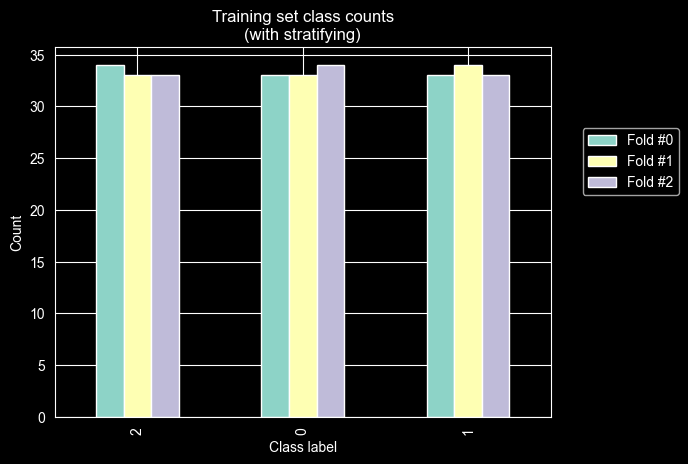

In [22]:
train_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Training set class counts\n(with stratifying)")

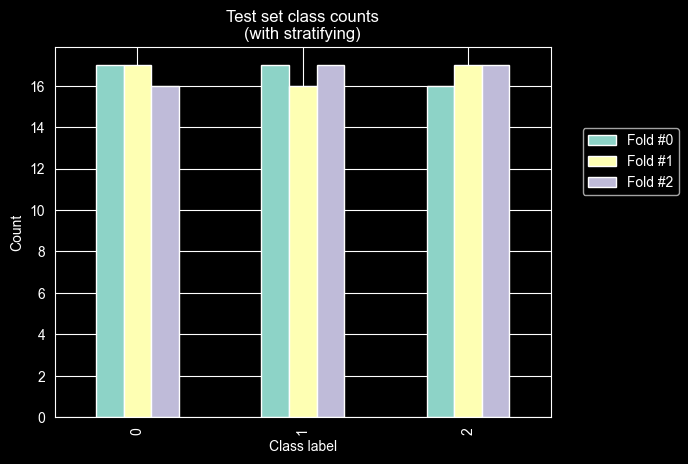

In [23]:
test_cv_counts.plot.bar()
plt.legend(bbox_to_anchor=(1.05, 0.8), loc="upper left")
plt.ylabel("Count")
_ = plt.title("Test set class counts\n(with stratifying)")